In [ ]:
!pip install pandas Sastrawi nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=26be2d6436f6db159d2e01ec2ef62fac20381b3ebc5c2720c1e34b6499ed863f
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import pandas as pd
import re
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
from langdetect import detect

nltk.download('stopwords')

# ========================
# 1. Load Data
# ========================
df = pd.read_csv("dataset_UTS.csv")

# ========================
# 2. Tools
# ========================
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set(stopwords.words('indonesian'))

# Tambahan stopword
stop_words = stop_words.union({
    'amp','sih', 'nya', 'mah'
})

# ========================
# 3. Kamus Slang → Baku
# ========================
slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "tdk": "tidak",
    "gak": "tidak",
    "bgt": "banget",
    "bgtt": "banget",
    "yg": "yang",
    "dr": "dari",
    "krn": "karena",
    "aja": "saja",
    "dll": "dan lain lain",
    "jgn": "jangan",
    "utk" : "untuk",
    "ya": "iya",
    "yaa": "iya",

    "gue": "saya",
    "gua": "saya",
    "gw": "saya",
    "aku": "saya",

    "lu": "kamu",
    "lo": "kamu",
    "elu": "kamu"
}

# ========================
# 4. Fungsi Deteksi Bahasa
# ========================
def is_indonesian(text):
    try:
        return detect(text) == 'id'
    except:
        return False

# ========================
# 5. Preprocessing
# ========================
def preprocess_text(text):

    text = str(text)

    # Filter bahasa Indonesia
    if not is_indonesian(text):
        return ""

    text = text.lower()

    # Cleaning dasar
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Hapus HTML encoding
    text = re.sub(r'\bamp\b', '', text)

    # Hapus laughter (wkwk, awokwok, dll)
    text = re.sub(r'\b[a-z]*w[kwo]+[a-z]*\b', '', text)

    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    # Normalisasi huruf berulang (aman)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    text = text.strip()

    # Tokenizing
    words = text.split()

    # Normalisasi slang → baku
    words = [slang_dict[word] if word in slang_dict else word for word in words]

    # Stopword removal (SETELAH normalisasi)
    words = [word for word in words if word not in stop_words]

    # Hapus kata pendek
    words = [word for word in words if len(word) > 2]

    # Stemming
    words = [stemmer.stem(word) for word in words]

    return " ".join(words)

# ========================
# 6. Apply
# ========================
df['clean_text'] = df['text'].apply(preprocess_text)

# Hapus baris kosong
df = df[df['clean_text'] != ""]

# ========================
# 7. Cek hasil
# ========================
print(df[['text', 'clean_text']].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                                text  \
0  @NyaiNeneng Anggota dpr tukang klaim CSR Bank²...   
1  @wibusangean @neohistoria_id sama aja dpr dari...   
2  @randomable_ DPR Dewan Pemalak Rakyat hadapi d...   
3  @Brotherwone @regar_op0sisi Jakarta (selatan p...   
4  padahal gedung dpr deket bgt stasiun palmerah ...   

                                          clean_text  
0  anggota dpr tukang klaim csr bank bumn swasta ...  
1  dpr gin gin kerja reshuffle kalo emg duduk kur...  
2       dpr dewan malak rakyat hadap demo mhs jantan  
3  jakarta selatan pusat daerah kawasan bagus kay...  
4  gedung dpr deket banget stasiun palmerah iya n...  


In [ ]:
# ========================
# 7. Simpan
# ========================
df.to_csv("dataset_UTS_clean.csv", index=False)


In [ ]:
print(f"Jumlah data bersih: {len(df)}")

Jumlah data bersih: 4791


**Topic Analysis**

In [ ]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt

In [ ]:
# Ubah clean_text jadi list of tokens
texts = df['clean_text'].apply(lambda x: x.split())

# Hapus dokumen kosong
texts = [text for text in texts if len(text) > 0]

In [ ]:
# Buat dictionary (mapping kata → id)
dictionary = corpora.Dictionary(texts)

# Filter kata yang terlalu jarang / terlalu sering (opsional tapi penting)
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Buat corpus (BoW)
corpus = [dictionary.doc2bow(text) for text in texts]

In [ ]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

In [ ]:
topics = lda_model.print_topics(num_words=10)

for i, topic in topics:
    print(f"Topik {i}: {topic}\n")

Topik 0: 0.055*"gedung" + 0.034*"demo" + 0.014*"bakar" + 0.013*"jalan" + 0.012*"aksi" + 0.012*"pagi" + 0.012*"massa" + 0.012*"info" + 0.011*"maaf" + 0.010*"kantor"

Topik 1: 0.064*"rakyat" + 0.021*"anggota" + 0.020*"iya" + 0.016*"demo" + 0.013*"perintah" + 0.012*"polisi" + 0.012*"udah" + 0.011*"presiden" + 0.009*"salah" + 0.009*"banget"

Topik 2: 0.041*"tunjang" + 0.035*"anggota" + 0.033*"gaji" + 0.027*"pajak" + 0.020*"rakyat" + 0.019*"negara" + 0.014*"partai" + 0.012*"jabat" + 0.011*"dasar" + 0.011*"uang"

Topik 3: 0.027*"bubar" + 0.019*"anggota" + 0.015*"aset" + 0.014*"partai" + 0.013*"orang" + 0.013*"ketua" + 0.013*"ampas" + 0.013*"iya" + 0.011*"ganti" + 0.011*"indonesia"

Topik 4: 0.031*"rumah" + 0.029*"jarah" + 0.019*"anjing" + 0.019*"lain" + 0.018*"iya" + 0.016*"kalo" + 0.014*"anggota" + 0.014*"banget" + 0.013*"orang" + 0.012*"tolol"



In [ ]:
coherence_scores = []
topic_range = range(2, 11)  # coba dari 2 sampai 10 topik

for k in topic_range:
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10
    )

    coherence_model = CoherenceModel(
        model=model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"Topik {k} → Coherence Score: {score:.4f}")

Topik 2 → Coherence Score: 0.3448
Topik 3 → Coherence Score: 0.3547
Topik 4 → Coherence Score: 0.3602
Topik 5 → Coherence Score: 0.3573
Topik 6 → Coherence Score: 0.3377
Topik 7 → Coherence Score: 0.3516
Topik 8 → Coherence Score: 0.3369
Topik 9 → Coherence Score: 0.3299
Topik 10 → Coherence Score: 0.3501


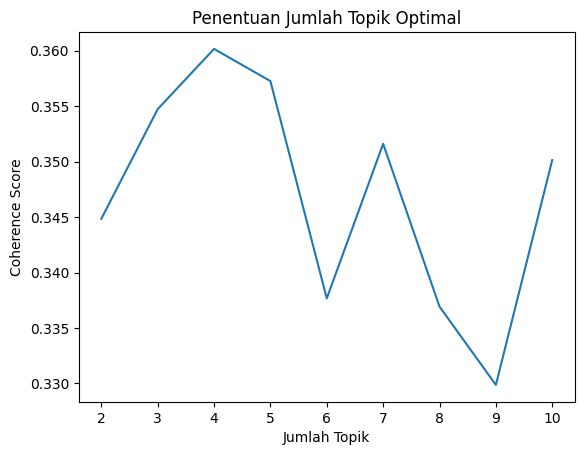

In [ ]:
plt.plot(topic_range, coherence_scores)
plt.xlabel("Jumlah Topik")
plt.ylabel("Coherence Score")
plt.title("Penentuan Jumlah Topik Optimal")
plt.show()

##**CEK DULU JUMLAH K OPTIMALNYA BERAPA**

In [ ]:
# Train final model (5 topik)
lda_final = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=42,
    passes=10,
    alpha='auto'
)

# Tampilkan topik
topics = lda_final.print_topics(num_words=10)
for topic in topics:
    print(f"Topik {topic[0]}: {topic[1]}")

Topik 0: 0.042*"gedung" + 0.032*"demo" + 0.013*"bakar" + 0.009*"biar" + 0.009*"kantor" + 0.009*"kerja" + 0.008*"pagi" + 0.008*"rumah" + 0.008*"polisi" + 0.007*"jalan"
Topik 1: 0.060*"rakyat" + 0.021*"iya" + 0.021*"anggota" + 0.014*"demo" + 0.013*"perintah" + 0.012*"udah" + 0.012*"polisi" + 0.011*"presiden" + 0.011*"kalo" + 0.009*"banget"
Topik 2: 0.034*"tunjang" + 0.034*"anggota" + 0.024*"rumah" + 0.024*"pajak" + 0.021*"gaji" + 0.019*"jarah" + 0.013*"rakyat" + 0.012*"demo" + 0.012*"negara" + 0.010*"jabat"
Topik 3: 0.022*"bubar" + 0.020*"anggota" + 0.020*"partai" + 0.017*"orang" + 0.015*"iya" + 0.013*"gaji" + 0.010*"aset" + 0.010*"ketua" + 0.009*"pilih" + 0.009*"presiden"


In [ ]:
# Distribusi topik tiap dokumen
doc_topics = [lda_final.get_document_topics(doc) for doc in corpus]

# Contoh lihat 5 dokumen pertama
for i, doc in enumerate(doc_topics[:4]):
    print(f"Dokumen {i}: {doc}")

Dokumen 0: [(0, np.float32(0.020001981)), (1, np.float32(0.08135249)), (2, np.float32(0.6195263)), (3, np.float32(0.27911916))]
Dokumen 1: [(1, np.float32(0.39590472)), (2, np.float32(0.011131409)), (3, np.float32(0.5842116))]
Dokumen 2: [(0, np.float32(0.027997432)), (1, np.float32(0.8913631)), (2, np.float32(0.03588196)), (3, np.float32(0.044757526))]
Dokumen 3: [(1, np.float32(0.040628355)), (2, np.float32(0.43672693)), (3, np.float32(0.51526314))]


In [ ]:
doc_topics = []

for doc in corpus:
    topics = lda_final.get_document_topics(doc)
    doc_topics.append(topics)

df['topics'] = doc_topics

**Visualisasi**

In [ ]:
!pip install pyLDAvis


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 36.7 MB/s eta 0:00:00


In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(lda_final, corpus, dictionary)
vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.095480 -0.124869       1        1  46.352238
3     -0.161628 -0.046254       2        1  20.792348
2      0.002984  0.250397       3        1  19.214328
0      0.254124 -0.079275       4        1  13.641086, topic_info=        Term         Freq        Total Category  logprob  loglift
45    gedung   282.000000   282.000000  Default  30.0000  30.0000
54   tunjang   359.000000   359.000000  Default  29.0000  29.0000
22    rakyat  1420.000000  1420.000000  Default  28.0000  28.0000
119    pajak   222.000000   222.000000  Default  27.0000  27.0000
183    rumah   279.000000   279.000000  Default  26.0000  26.0000
..       ...          ...          ...      ...      ...      ...
420     gara    27.324454    47.812101   Topic4  -5.4189   1.4326
300     aksi    29.142809   100.751140   Topic4  -5.3545   0.7516
347  kemarin    27.184081    59.504972   Topic4  -5.4240   1.2087
40    banget    29.266660   266.259380   Topic4  -5.3502  -0.2159
10       iya    30.009412   613.568193   Topic4  -5.3252  -1.0257

[284 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
1172      1  0.991256       adu
564       3  0.858622   agustus
564       4  0.133026   agustus
1062      4  0.959070       ajg
300       3  0.704707      aksi
...     ...       ...       ...
55        2  0.287872     wakil
55        3  0.024675     wakil
1583      3  0.091003       wfh
1583      4  0.879693       wfh
804       4  0.920499  zonauang

[433 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 3, 1])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

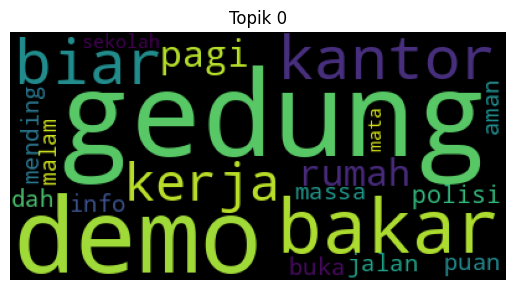

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

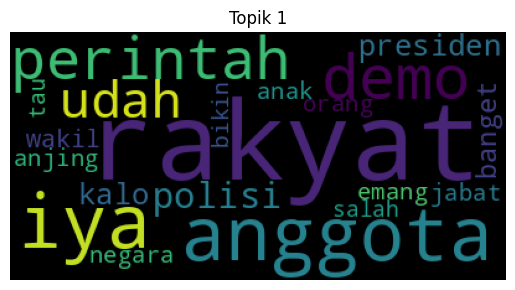

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

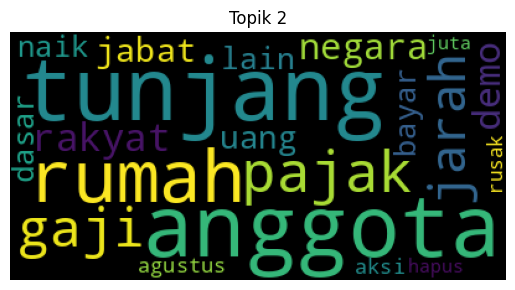

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

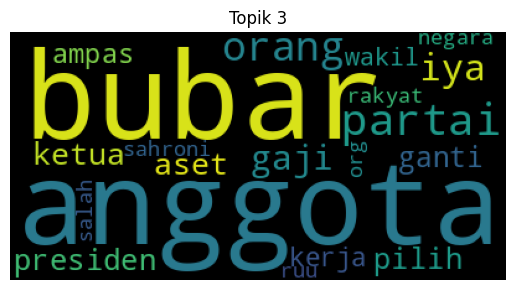

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from wordcloud import WordCloud

optimal_k = 4

for t in range(optimal_k):
    plt.figure()
    plt.imshow(WordCloud().fit_words(dict(lda_final.show_topic(t, 20))))
    plt.axis("off")
    plt.title(f"Topik {t}")
    plt.show()

In [ ]:
for i in range(4):
    words = lda_final.show_topic(i, topn=10)
    words = [w[0] for w in words]
    print(f"Topik {i}: {', '.join(words)}")

Topik 0: gedung, demo, bakar, biar, kantor, kerja, pagi, rumah, polisi, jalan
Topik 1: rakyat, iya, anggota, demo, perintah, udah, polisi, presiden, kalo, banget
Topik 2: tunjang, anggota, rumah, pajak, gaji, jarah, rakyat, demo, negara, jabat
Topik 3: bubar, anggota, partai, orang, iya, gaji, aset, ketua, pilih, presiden


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag